## Effective Medium Theories

The Maxwell-Garnett and Bruggemann theories are implemented here. Their permittivities are plotted for different fill fractions of the inclusion material, along with the Reflectance, Transmittance and Absorptance for a Vacuum - SiO2/Gold Inclusion - Vacuum system, for which the Gold/SiO2 system is 10 nm thick. It is assumed that the gold inclusions are spherical in shape, and that gold is the only inclusion. 

First, the relevant packages are imported, including the MaterialParameters database and the OpticsEquations file containing implementations of the Fresnel and Fabry-Perot expressions. 

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import MaterialParameters as mp
import OpticsEquations as oe

plt.rcParams["figure.figsize"]=(12,6)  #Globally rescale all images to this size. 

An array of frequencies/photon energies is created, while other relevant parameters are defined. A function to plot the relative permittivity is created as well, to save time on writing code, if needed.

In [15]:
#Define parameters used in EMTs.
freqs = np.arange(0.01, 40, 0.01)
GoldPerm = mp.Au.epsilon(freqs) #Metal Permittivity.
SiO2Perm = (1.54)**2 #Dielectric permittivity.
fill = [0, 0.2, 0.35, 0.5, 0.8, 1]  #Array of fill fractions


#Define a permittivity plotting function.
def PlotPerm(x=freqs, y = 12, title="Relative Permittivity", start=1, end=20):
    plt.plot(x, np.real(y), label="Real")
    plt.plot(x, np.imag(y), label="Imag.")
    plt.grid(True)
    plt.title(title)
    plt.xlabel("Frequency [eV]")
    plt.legend(loc="best")
    plt.xlim(start,end)
    plt.ylim(-10, 12)

Make a quick plot of the permittivity of pure gold from the materials database. This will be useful to compare to when we consider fill fractions leading to 100 percent gold. 

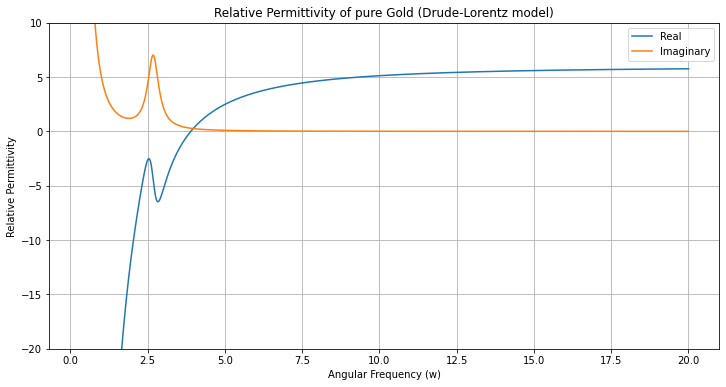

In [16]:
mp.Au.plot(end=20, title="Relative Permittivity of pure Gold (Drude-Lorentz model)", start=0.3)
plt.ylim(-20,10);

#### Maxwell-Garnett Theory
The Maxwell-Garnett permittivity is defined as 
$$\epsilon_{eff} = \epsilon_{h} \left( \frac{1+2f\eta}{1-f\eta} \right) \quad\quad \rm{where} \quad \eta = \frac{\epsilon_{i}-\epsilon_{h}}{\epsilon_{i}+2\epsilon_{h}}$$
for one spherically shaped inclusion in a host material.   

This equation is implemented below, for which the host material permittivity is set at a default value of $1$ as in a vacuum. 

In [17]:
def MG(ei, 
       eh = 1, #Default vacuum permittivity for host. 
       f = 0.1): #Defulat 10 percent fill fraction of the inclusion material.
    
    eta = (ei - eh) / (ei + 2*eh)
    eps = eh * (1 + 2*f*eta) / (1 - f*eta)
    return eps

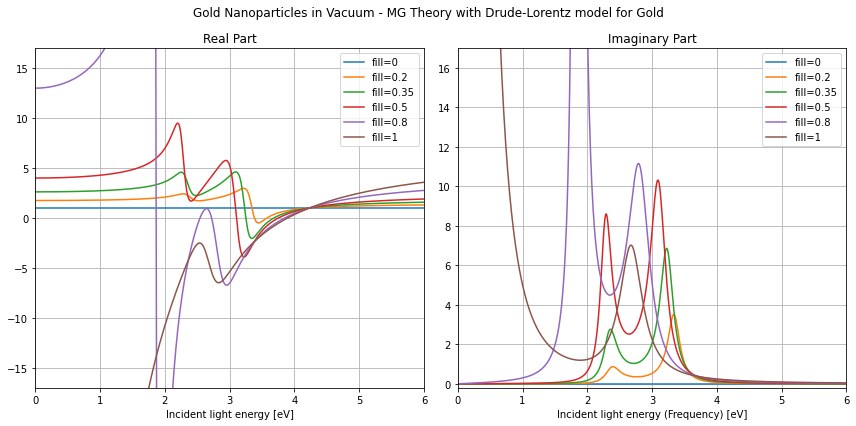

In [18]:
MGresults = dict()  #Create an empty dictionary to save the Maxwell-Garnett results.

for i in fill:
    MGresults[f"MG{i}"] = MG(f=i, ei=GoldPerm) #Save the Max-Gar results for different fill fractions.
    
#print(MGresults.keys())  #Print out dictionary keys as a check.



plt.subplot(1,2,1)
for j in fill:
    plt.plot(freqs, np.real(MGresults[f"MG{j}"]), label=f"fill={j}" )
    plt.legend(loc="best")
    plt.title("Real Part")
    plt.grid(True)
    plt.xlim(0,6)
    plt.ylim(-17,17)
    plt.xlabel("Incident light energy [eV]")
    
plt.subplot(1,2,2)
for j in fill:
    plt.plot(freqs, np.imag(MGresults[f"MG{j}"]), label=f"fill={j}" )
    plt.legend(loc="best")
    plt.title("Imaginary Part")
    plt.grid(True)
    plt.xlim(0,6)
    plt.ylim(-0.2,17)
    plt.xlabel("Incident light energy (Frequency) [eV]")
    
plt.suptitle("Gold Nanoparticles in Vacuum - MG Theory with Drude-Lorentz model for Gold")
plt.tight_layout()

Next, the reflectance, transmittance and absorptance for a system of gold inclusion in an SiO2 film modelled using the Maxwell-Garnett theory, sandwiched by a vacuum, is shown. The film thickness is 10nm and different fill fractions of the gold inclusions are shown. The Fabry-Perot expressions from the Optics Equations file are used. 

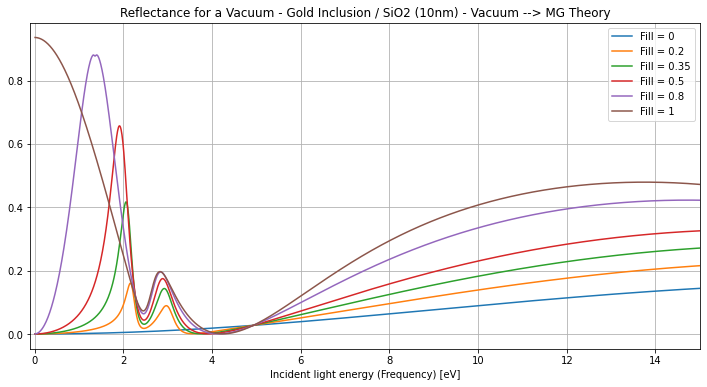

In [19]:
lams = oe.LfromW(freqs)  #Find wavelengths if we want to plot instead of frequencies.

MG2results = dict()  #Create an empty dictionary to save the Maxwell-Garnett results.

for i in fill:
    MG2results[f"MG2{i}"] = MG(f=i, eh=SiO2Perm, ei=GoldPerm) #Save the Max-Gar results for different fill fractions.

for f in fill:
    plt.plot(freqs, oe.FabryPerot(frequency=freqs , e0=1, e1 = MG2results[f"MG2{f}"], e2=1, extract="R",\
                              thickness=10, polarisation="p", angle=0), label=f"Fill = {f}" )
    plt.legend(loc="best")
    plt.xlim(-0.1,15)
    plt.grid(True)
    plt.xlabel("Incident light energy (Frequency) [eV]")
    plt.title("Reflectance for a Vacuum - Gold Inclusion / SiO2 (10nm) - Vacuum --> MG Theory") 

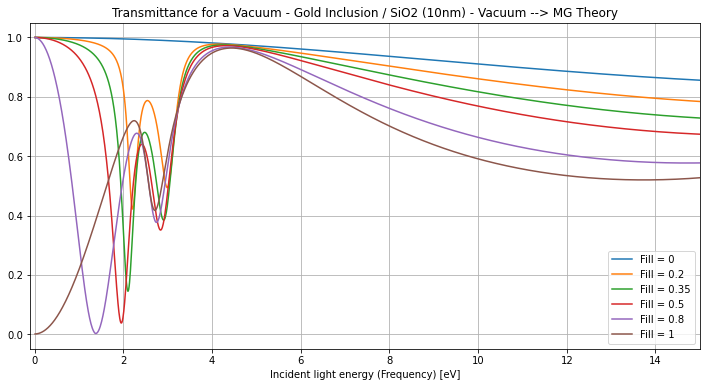

In [20]:
for f in fill:
    plt.plot(freqs, oe.FabryPerot(frequency=freqs , e0=1, e1 = MG2results[f"MG2{f}"], e2=1, extract="T",\
                              thickness=10, polarisation="p", angle=0), label=f"Fill = {f}" )
    plt.legend(loc="best")
    plt.xlim(-0.1,15)
    plt.grid(True)
    plt.xlabel("Incident light energy (Frequency) [eV]")
    plt.title("Transmittance for a Vacuum - Gold Inclusion / SiO2 (10nm) - Vacuum --> MG Theory") 

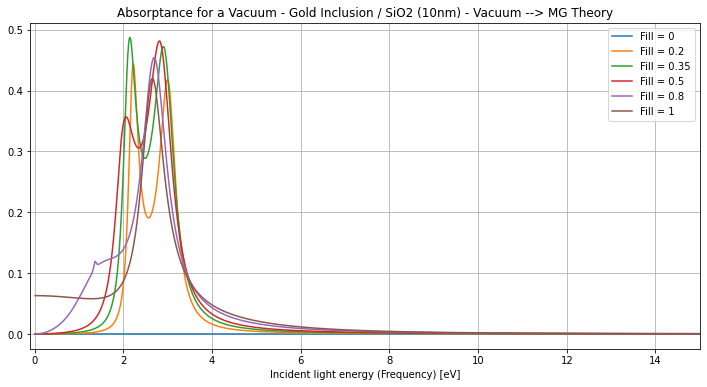

In [21]:
for f in fill:
    plt.plot(freqs, oe.FabryPerot(frequency=freqs , e0=1, e1 = MG2results[f"MG2{f}"], e2=1, extract="A",\
                              thickness=10, polarisation="p", angle=0), label=f"Fill = {f}" )
    plt.legend(loc="best")
    plt.xlim(-0.1,15)
    plt.grid(True)
    plt.xlabel("Incident light energy (Frequency) [eV]")
    plt.title("Absorptance for a Vacuum - Gold Inclusion / SiO2 (10nm) - Vacuum --> MG Theory") 

#### Bruggeman Theory

The Bruggeman equation for 3D inclusions is given as 

$$\epsilon_{eff} = \frac{b \pm \sqrt{8 \epsilon_{1} \epsilon_{2} + b^2}}{4} \quad\quad \rm{where} \quad b=(2f_1 - f_2)\epsilon_{1} + (2f_2 - f_1)\epsilon_{2}$$

where the composite is a mix of two different materials. 

The physical solution is given by the "plus sign" solution, since it can be proved that this satisfies the necessary conditions that 
$$\epsilon_{BG}\vert_{f_n = 1}  = \epsilon_{n}  \quad\quad \rm{and} \quad\quad Im(\epsilon_{BG}) >0$$

In order to obtain a smooth and continuous solution, two additional conditions must be met for this two material composition. Firstly, the total sum of the volume fractions must equal unity, so $f_1 + f_2 = 1$. This condition is unavoidable upon setting $f_1=f$ and $f_2 = 1-f$.

Also, the square root branch is defined by the condition that $0 \leq arg(\sqrt{z}) < \pi$. Therefore, for each expression of $\sqrt{8\epsilon_{1} \epsilon_{2} + b^2}$, a check is made whether it satisfies this angular criterion. If it is less than zero, it is switched to the positive solution. If it is greater than pi, the value of pi is removed until it is its equivalent value between 0 and pi. 

In [27]:
def BG(ei, 
       eh = 1, #Default vaccum permittivity for host. 
       f = 0.1): #Default fill fraction of 10 percent. 
    
    
    b = (2*f - (1-f) )*ei + (2*(1-f) - f)*eh
    z = 8*ei*eh + b**2
    sqrtz = np.sqrt(z)
    
    #Check the angle of sqrt(z) and make positive and between 0 and pi if necessary. 
    for i in range(0,len(sqrtz)):
        if np.angle(sqrtz[i])<0:
            sqrtz[i] = -sqrtz[i]
        elif np.angle(sqrtz[i])>=np.pi:
            while np.angle(sqrtz[i])>=np.pi:
                sqrtz[i] = sqrtz[i] - np.pi
            
    eps = (b + sqrtz) / 4
    
    return eps

Plot the effective permittivities using the Bruggeman theory for gold inclusions of varying fill fractions in a vacuum. 

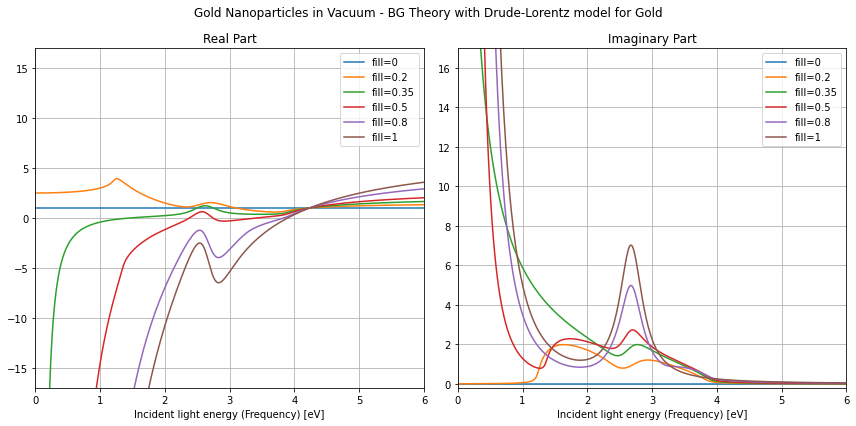

In [28]:
BGresults = dict()  #Create an empty dictionary to save the Maxwell-Garnett results.

for i in fill:
    BGresults[f"BG{i}"] = BG(f=i, ei=GoldPerm) #Save the Max-Gar results for different fill fractions.
    
#print(MGresults.keys())  #Print out dictionary keys as a check.



plt.subplot(1,2,1)
for j in fill:
    plt.plot(freqs, np.real(BGresults[f"BG{j}"]), label=f"fill={j}" )
    plt.legend(loc="best")
    plt.title("Real Part")
    plt.grid(True)
    plt.xlim(0,6)
    plt.ylim(-17,17)
    plt.xlabel("Incident light energy (Frequency) [eV]")
    
plt.subplot(1,2,2)
for j in fill:
    plt.plot(freqs, np.imag(BGresults[f"BG{j}"]), label=f"fill={j}" )
    plt.legend(loc="best")
    plt.title("Imaginary Part")
    plt.grid(True)
    plt.xlim(0,6)
    plt.ylim(-0.2,17)
    plt.xlabel("Incident light energy (Frequency) [eV]")
    
plt.suptitle("Gold Nanoparticles in Vacuum - BG Theory with Drude-Lorentz model for Gold")
plt.tight_layout()

Plot the reflectance, transmittance and absorptance for a system of gold inclusion in an SiO2 film modelled using Bruggeman theory, sandwiched by a vacuum. The film thickness is 10nm and different fill fractions of the gold inclusions are shown. The Fabry-Perot expressions from the Optics Equations module are used. 

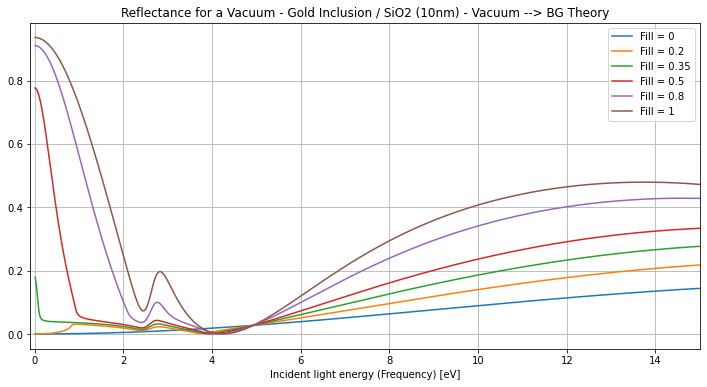

In [29]:
BG2results = dict()  #Create an empty dictionary to save the Maxwell-Garnett results.

for i in fill:
    BG2results[f"BG2{i}"] = BG(f=i, eh=SiO2Perm, ei=GoldPerm) #Save the Bruggeman results for different fill fractions.

for f in fill:
    plt.plot(freqs, oe.FabryPerot(frequency=freqs , e0=1, e1 = BG2results[f"BG2{f}"], e2=1, extract="R",\
                              thickness=10, polarisation="p", angle=0), label=f"Fill = {f}" )
    plt.legend(loc="best")
    plt.xlim(-0.1, 15)
    plt.grid(True)
    plt.xlabel("Incident light energy (Frequency) [eV]")
    plt.title("Reflectance for a Vacuum - Gold Inclusion / SiO2 (10nm) - Vacuum --> BG Theory") 

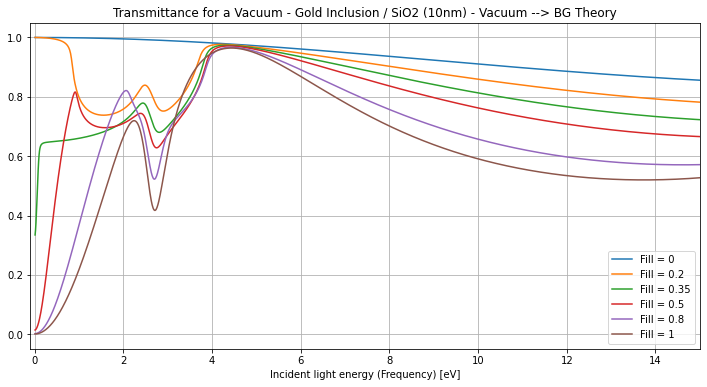

In [30]:
for f in fill:
    plt.plot(freqs, oe.FabryPerot(frequency=freqs , e0=1, e1 = BG2results[f"BG2{f}"], e2=1, extract="T",\
                              thickness=10, polarisation="p", angle=0), label=f"Fill = {f}" )
    plt.legend(loc="best")
    plt.xlim(-0.1, 15)
    plt.grid(True)
    plt.xlabel("Incident light energy (Frequency) [eV]")
    plt.title("Transmittance for a Vacuum - Gold Inclusion / SiO2 (10nm) - Vacuum --> BG Theory") 

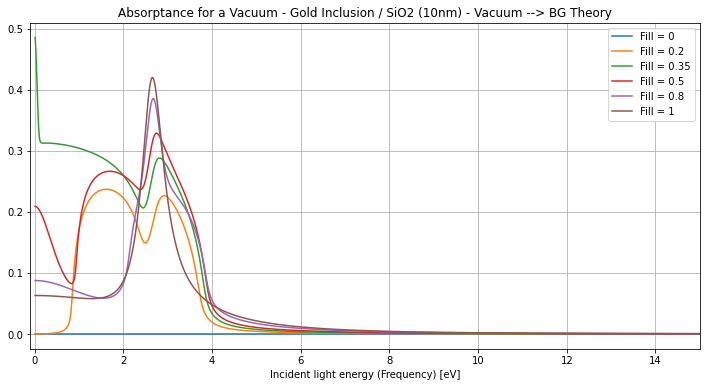

In [31]:
for f in fill:
    plt.plot(freqs, oe.FabryPerot(frequency=freqs , e0=1, e1 = BG2results[f"BG2{f}"], e2=1, extract="A",\
                              thickness=10, polarisation="p", angle=0), label=f"Fill = {f}" )
    plt.legend(loc="best")
    plt.xlim(-0.1, 15)
    plt.grid(True)
    plt.xlabel("Incident light energy (Frequency) [eV]")
    plt.title("Absorptance for a Vacuum - Gold Inclusion / SiO2 (10nm) - Vacuum --> BG Theory") 